# 06 — Final evaluation on the test split (Phase 7)

**Owner:** M4 (+ all) · **Plan:** Phase 7 · **Split:** frozen 70/15/15 (hash `b74d294f…`).

Every configuration below was chosen on **validation** only. This notebook is the first and only time the 630 test clips are scored. The best model for the significance tests is also fixed in advance, from validation: **A5** (lowest seed-mean validation log loss).

| Approach | Final run | Seeds |
|---|---|---|
| A1 MFCC statistics + logistic regression | A1-R0-03 | 1 (deterministic) |
| A2 GMM-HMM | A2-R2-03 | 1 (deterministic) |
| A3 BiLSTM + attention | A3-R3-01 (= A3-R2-12) | 42, 13, 7 |
| A4 TC-ResNet | A4-R3-01 (= A4-R2-05) | 42, 13, 7 |
| A5 XLS-R, fine-tuned | A5-R3-01 (= A5-R2-03) | 42, 13, 7 |

**How the numbers are made.** Part 1 scores each final model once and writes `results/predictions/<run>_seed<s>_test.csv`, using the temperature each run fitted on validation. Part 2 trains the data-size curve (round R4). Part 3 builds every table and figure **from the prediction files alone**.

Parts 1 and 2 are skipped for anything already scored, so re-running the notebook takes about a minute and needs no GPU. On the first run (a Kaggle T4), any missing checkpoint is rebuilt by retraining its logged configuration: A5's checkpoints (1.2 GB each) are not committed. Before a rebuilt or loaded model scores the test split, it must reproduce its logged validation predictions.

In [1]:
import glob, os, shutil, sys, subprocess

REPO_URL = "https://github.com/Hassan-Adelani-Luqman/nlp-sequential-modeling-group21.git"
REPO_DIR = "nlp-sequential-modeling-group21"
if os.path.isdir("/kaggle/input") or "google.colab" in sys.modules:
    # A code-snapshot dataset attached on Kaggle takes precedence over GitHub (lets you run code before it is pushed).
    snapshot = glob.glob("/kaggle/input/**/src/train_torch.py", recursive=True) if os.path.isdir("/kaggle/input") else []
    zipped = glob.glob("/kaggle/input/**/group21-code*.zip", recursive=True) if os.path.isdir("/kaggle/input") else []
    if not snapshot and zipped:  # the archive was not unpacked on upload: unpack it ourselves
        import zipfile
        zipfile.ZipFile(zipped[0]).extractall("/tmp/snapshot")
        snapshot = glob.glob("/tmp/snapshot/**/src/train_torch.py", recursive=True)
    if snapshot:
        REPO_DIR = "/tmp/" + REPO_DIR   # outside /kaggle/working, so only results are saved as outputs
        if not os.path.isdir(REPO_DIR):
            shutil.copytree(os.path.dirname(os.path.dirname(snapshot[0])), REPO_DIR)
        print("using code snapshot:", os.path.dirname(os.path.dirname(snapshot[0])))
    elif not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "-q", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
    if os.path.isdir("/kaggle/working"):
        # Kaggle writes outputs to /kaggle/working, which starts empty: seed it with the repo's logged runs
        # (and any checkpoints shipped with the code snapshot) so finished runs are reused, not retrained.
        for folder in ("results", "checkpoints"):
            if os.path.isdir(folder):
                shutil.copytree(folder, os.path.join("/kaggle/working", folder), dirs_exist_ok=True)
        os.environ.setdefault("SWN_CACHE_DIR", "/tmp/swn_feature_cache")  # recomputable: keep it out of the outputs
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

In [2]:
assert os.path.exists("src/models/wav2vec2.py"), "the attached code snapshot (or clone) is out of date"
import copy, gc, json, pickle, platform, time
import numpy as np, pandas as pd, torch, yaml
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display
from sklearn.metrics import log_loss, roc_curve
import transformers

from src.augment import LogMelAugment, WaveAugment
from src.data import label_names, load_splits, stratified_subset
from src.evaluate import (KEY_PAIRS, bootstrap_ci, compute_metrics, cross_fitted_temperature, holm_correction,
                          load_predictions, mcnemar_test, pair_confusion, paired_bootstrap, plot_confusion_matrix,
                          reliability_curve, save_predictions, softmax)
from src.experiment import ExperimentRunner
from src.features import Standardizer, cached_features, extract, utterance_cmvn
from src.models.baselines import GMMHMMClassifier, make_a1
from src.models.bilstm import BiLSTMAttention
from src.models.tcresnet import TCResNet
from src.models.wav2vec2 import Wav2Vec2Classifier, count_all_parameters, tiny_config
from src.paths import CONFIGS_DIR, REPO_ROOT, checkpoints_dir, results_dir
from src.plotting import INK_MUTED, INK_SECONDARY, MODEL_COLORS, apply_style, save_figure
from src.train_torch import TrainConfig, load_checkpoint, predict_logits, train_model
from src.utils import build_experiment_table, get_device, gpu_name, record_test_metrics, set_seed

transformers.logging.set_verbosity_error()
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
SEED, MEMBER, NOTEBOOK = 42, "M4", "notebooks/06_results_error_analysis.ipynb"
SEEDS = (42, 13, 7)
RESCORE = False   # True = score the test split again even if prediction files exist
SMOKE = os.environ.get("SWN_SMOKE") == "1"   # tiny end-to-end check (use with SWN_OUTPUT_DIR)
set_seed(SEED)
apply_style()
torch.set_num_threads(os.cpu_count() or 4)

NAMES = label_names()
splits = load_splits()
train, val, test = splits["train"], splits["val"], splits["test"]
if SMOKE:
    take = lambda df, n: df.groupby("label_id", group_keys=False).head(n).reset_index(drop=True)
    train, val, test = take(train, 10), take(val, 5), take(test, 2)
y_tr, y_val, y_test = (d.label_id.to_numpy() for d in (train, val, test))
DEVICE = get_device()
GPU = torch.cuda.is_available()
NUM_WORKERS = 2 if (os.path.isdir("/kaggle/input") or "google.colab" in sys.modules) else 0
APPROACHES = ("A1", "A2", "A3", "A4", "A5")
FINAL = {"A1": ("A1-R0-03", (42,)), "A2": ("A2-R2-03", (42,)),
         "A3": ("A3-R3-01", SEEDS), "A4": ("A4-R3-01", SEEDS), "A5": ("A5-R3-01", SEEDS)}
print(f"train {len(train)} · val {len(val)} · test {len(test)} · device {gpu_name()} · "
      f"Python {platform.python_version()} · torch {torch.__version__}")

C:\Users\Luqma\dev\projects\coursework\nlp-sequential-modeling-group21\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


train 2940 · val 630 · test 630 · device cpu · Python 3.14.3 · torch 2.14.0+cpu


In [3]:
def find(kind, name):
    '''A results file from the output folder, or the repo copy if the output folder has none.'''
    for base in (results_dir(), REPO_ROOT / "results"):
        if (base / kind / name).exists():
            return base / kind / name
    return results_dir() / kind / name


def logged(exp_id, seed=SEED):
    return json.loads(find("metrics", f"{exp_id}_seed{seed}_val.json").read_text(encoding="utf-8"))


def checkpoint_file(name):
    candidates = [checkpoints_dir() / name, REPO_ROOT / "checkpoints" / name]
    return next((c for c in candidates if c.exists()), candidates[0])


def rows_of(full, sub):
    '''Rows of a full-split feature array (or list) for a subset of its clips, so subsets reuse cached features.'''
    pos = pd.Index(train.id).get_indexer(sub.id)
    assert (pos >= 0).all()
    return [full[i] for i in pos] if isinstance(full, list) else full[pos]


# ---- each approach's own recipe, exactly as in its notebook (02, 03, 04, 05)
def augmenter(approach, cfg, seed):
    kind, feature = cfg["augment"], cfg["features"]["feature"]
    if kind == "none":
        return None
    if approach == "A5":
        return WaveAugment(seed=seed)                                            # 05: "wave"
    fill = "channel" if (approach == "A4" and feature != "logmel") else "global"  # 04: per-channel fill for MFCCs
    if kind == "specaugment":
        return LogMelAugment.specaugment_only(seed=seed, fill=fill)
    if kind == "full":
        return LogMelAugment(seed=seed, fill=fill, noise_snr_db=(10.0, 30.0) if feature == "logmel" else None)
    raise ValueError(kind)


def network(approach, cfg, n_features, pretrained=True):
    if approach == "A3":
        return BiLSTMAttention(n_features=n_features, **cfg["model"])
    if approach == "A4":
        return TCResNet(n_features=n_features, **cfg["model"])
    if SMOKE and pretrained:   # smoke runs train a tiny random wav2vec 2.0; checkpoints always load the real one
        return Wav2Vec2Classifier(config=tiny_config(), **{k: v for k, v in cfg["model"].items() if k != "backbone"})
    return Wav2Vec2Classifier(**cfg["model"], pretrained=pretrained)


def train_config(approach, cfg, seed):
    extra = {"standardize": False, "eval_batch_size": 32} if approach == "A5" else {}
    return TrainConfig(**{**cfg["train"], "seed": seed, "num_workers": NUM_WORKERS, **extra,
                          **({"epochs": 1} if SMOKE else {})})


def fit_neural(approach, cfg, seed, X_tr, y, X_va, checkpoint=None):
    return train_model(lambda: network(approach, cfg, X_tr.shape[-1]), X_tr, y, X_va, y_val,
                       train_config(approach, cfg, seed), augment=augmenter(approach, cfg, seed), device=DEVICE,
                       checkpoint=checkpoint, verbose=False)


def a2_sequences(cfg, df, scaler=None):
    seqs = list(cached_features(df, **cfg["features"]))
    seqs = utterance_cmvn(seqs) if cfg["cmvn"] else seqs
    scaler = scaler or Standardizer().fit(seqs)
    return scaler.transform(seqs), scaler


def free_gpu():
    gc.collect()
    if GPU:
        torch.cuda.empty_cache()

## Part 1 — score the test split once
For each final run and seed:
1. Load (or rebuild) the model.
2. Check that it reproduces its logged validation predictions.
3. Score the test split, with the temperature the run fitted on validation. The uncalibrated test probabilities are saved too, for the reliability diagrams.

When the test predictions already exist (for example from the Kaggle run) and the model is available on this machine, the model is run once more. It must give the same validation and test labels as before, which checks the result across machines (GPU against CPU). Every check is saved in `results/metrics/test_scoring_checks.csv` and reused afterwards.

In [4]:
CHECKS = find("metrics", "test_scoring_checks.csv")
known = {(r["run"], int(r["seed"])): r for r in pd.read_csv(CHECKS).to_dict("records")} if CHECKS.exists() and not SMOKE else {}


def model_outputs(approach, exp_id, seed, rebuild):
    '''Validation predictions, test probabilities (calibrated and raw) and how the model was obtained, or None.'''
    rec = logged(exp_id, seed)
    cfg, extra = rec["params"], rec["extra"]
    if approach == "A1":
        X_tr, X_va, X_te = (cached_features(d, **cfg["features"]) for d in (train, val, test))
        model = make_a1(cfg["kind"]).set_params(clf__C=extra["best_params"]["C"]).fit(X_tr, y_tr)
        val_probs, test_p = model.predict_proba(X_va), model.predict_proba(X_te)
        return val_probs.argmax(1), val_probs, test_p, test_p, "refitted"   # deterministic; no temperature scaling
    if approach == "A2":
        s_tr, scaler = a2_sequences(cfg, train)
        s_va, _ = a2_sequences(cfg, val, scaler)
        s_te, _ = a2_sequences(cfg, test, scaler)
        path = checkpoint_file(f"{exp_id}_seed{seed}_hmm.pkl")
        if path.exists():
            hmm, status = pickle.loads(path.read_bytes()), "loaded"
        elif rebuild:
            print(f"{path.name} not found: refitting the HMM (about 10 minutes on CPU)")
            hmm, status = GMMHMMClassifier(n_states=cfg["n_states"], n_mix=cfg["n_mix"], seed=SEED).fit(s_tr, y_tr), "refitted"
            path.parent.mkdir(parents=True, exist_ok=True)
            path.write_bytes(pickle.dumps(hmm))
        else:
            return None
        val_scores, test_scores = hmm.scores(s_va), hmm.scores(s_te)
        val_probs = cross_fitted_temperature(val_scores, y_val, seed=SEED)[0] if not SMOKE else softmax(val_scores)
        return val_scores.argmax(1), val_probs, softmax(test_scores, extra["temperature"]), softmax(test_scores), status
    model_cfg = {k: cfg[k] for k in ("features", "model", "train", "augment")}
    X_va, X_te = cached_features(val, **cfg["features"]), cached_features(test, **cfg["features"])
    path = checkpoint_file(f"{exp_id}_seed{seed}.pt")
    if path.exists():
        model, scaler, _ = load_checkpoint(path, lambda: network(approach, model_cfg, X_va.shape[-1], pretrained=False),
                                           device=DEVICE)
        status = "loaded"
    elif rebuild and (approach != "A5" or GPU):
        print(f"{path.name} not found: rebuilding it by retraining the logged configuration")
        X_tr = cached_features(train, **cfg["features"])
        result = fit_neural(approach, model_cfg, seed, X_tr, y_tr, X_va, checkpoint=checkpoints_dir() / path.name)
        model, scaler, status = result.model, result.scaler, "rebuilt"
    else:
        return None
    batch = 32 if approach == "A5" else 256
    val_logits = predict_logits(model, X_va, scaler, batch_size=batch, device=DEVICE)
    test_logits = predict_logits(model, X_te, scaler, batch_size=batch, device=DEVICE)
    del model
    free_gpu()
    val_probs = cross_fitted_temperature(val_logits, y_val, seed=seed)[0] if not SMOKE else softmax(val_logits)
    return val_logits.argmax(1), val_probs, softmax(test_logits, extra["temperature"]), softmax(test_logits), status


def score_final(approach):
    '''Score each seed once; a reused test file is re-verified once if its model is available, then the check is cached.'''
    exp_id, seeds = FINAL[approach]
    rows = []
    for seed in seeds:
        out = find("predictions", f"{exp_id}_seed{seed}_test.csv")
        reuse = out.exists() and not RESCORE
        if reuse and (exp_id, seed) in known:
            rows.append(known[(exp_id, seed)])
            continue
        res = model_outputs(approach, exp_id, seed, rebuild=not reuse)
        if res is None:
            note = "reused (model not available here to re-verify)" if reuse else "skipped (no checkpoint, no GPU)"
            print(f"{exp_id} seed {seed}: {note}")
            rows.append({"approach": approach, "run": exp_id, "seed": seed, "status": note})
            continue
        val_pred, val_probs, test_p, test_raw, status = res
        # The model must reproduce its logged validation run before its test scores count.
        logged_df, logged_probs = load_predictions(find("predictions", f"{exp_id}_seed{seed}_val.csv"))
        logged_df = logged_df.set_index("id").loc[val.id]
        row = {"approach": approach, "run": exp_id, "seed": seed, "status": status,
               "val labels as logged": float((val_pred == logged_df["y_pred"].to_numpy()).mean()),
               "val max |Δp|": float(np.abs(val_probs - logged_probs).max()) if not SMOKE else float("nan")}
        if reuse:   # verify the saved test predictions instead of overwriting them
            saved_df, saved = load_predictions(out)
            row.update({"status": f"verified ({status})",
                        "test labels as saved": float((test_p.argmax(1) == saved.argmax(1)).mean()),
                        "test max |Δp|": float(np.abs(test_p - saved).max())})
            test_p = saved
        else:
            save_predictions(exp_id, seed, "test", test.id, y_test, test_p, NAMES)
            save_predictions(exp_id, seed, "test-uncalibrated", test.id, y_test, test_raw, NAMES)
        m = compute_metrics(y_test, test_p, NAMES)
        if not SMOKE:
            record_test_metrics(exp_id, seed, m)
        rows.append({**row, "test log loss": m["log_loss"], "test accuracy": m["accuracy"]})
    return rows


scoring = pd.DataFrame([row for a in APPROACHES for row in score_final(a)])
if not SMOKE:
    scoring.to_csv(results_dir() / "metrics" / "test_scoring_checks.csv", index=False)
display(scoring)
if "val labels as logged" in scoring and not SMOKE:   # smoke runs refit A1 on a subset, so they cannot match
    # A saved checkpoint (or a deterministic refit) must reproduce its logged validation predictions exactly, and a
    # re-verified model its saved test labels. A rebuilt model is retrained with the same seed; differences are reported.
    exact = scoring[~scoring.status.astype(str).str.contains("rebuilt|reused|skipped")]
    assert (exact["val labels as logged"] == 1.0).all(), "a saved model does not reproduce its logged validation predictions"
    if "test labels as saved" in exact:
        assert (exact["test labels as saved"].dropna() == 1.0).all(), "a model does not reproduce its saved test predictions"
    for _, r in scoring[scoring.status.astype(str).str.contains("rebuilt")].iterrows():
        print(f"{r['status']} {r['run']} seed {r['seed']}: {r['val labels as logged']:.2%} of validation labels as logged, "
              f"max |Δp| {r['val max |Δp|']:.2g}")

,approach,run,seed,status,val labels as logged,val max |Δp|,test labels as saved,test max |Δp|,test log loss,test accuracy
0,A1,A1-R0-03,42,verified (refitted),1.0,1.110223e-16,1.0,0.000060,0.699718,0.795238
1,A2,A2-R2-03,42,verified (loaded),1.0,1.110223e-16,1.0,0.000302,0.185716,0.965079
2,A3,A3-R3-01,42,verified (loaded),1.0,8.105072e-04,1.0,0.001076,0.165772,0.961905
3,A3,A3-R3-01,13,verified (loaded),1.0,4.335595e-04,1.0,0.001155,0.181236,0.957143
4,A3,A3-R3-01,7,verified (loaded),1.0,5.898533e-04,1.0,0.000771,0.164005,0.961905
5,A4,A4-R3-01,42,verified (loaded),1.0,8.649324e-04,1.0,0.000925,0.106448,0.969841
6,A4,A4-R3-01,13,verified (loaded),1.0,9.920292e-04,1.0,0.001235,0.114227,0.969841
7,A4,A4-R3-01,7,verified (loaded),1.0,1.106557e-03,1.0,0.001288,0.154393,0.949206
8,A5,A5-R3-01,42,verified (loaded),1.0,2.440481e-03,1.0,0.002321,0.092097,0.980952
9,A5,A5-R3-01,13,verified (loaded),1.0,9.787610e-03,1.0,0.006531,0.093196,0.980952


## Part 2 — data-size curve (round R4)
How much labelled speech does each approach need? Each **final configuration**, unchanged, is retrained on 10%, 25% and 50% of the training clips: about 24, 61 and 122 clips per word, against 245 for the full split.
- The subsets are stratified by word and nested: the 10% subset is part of the 25% subset, which is part of the 50% subset.
- The recipe is kept fixed (epochs, schedule, early stopping), so smaller subsets also get fewer optimisation steps, as happens when data is scarce.
- Validation still selects the epoch and fits the temperature. The 100% points are the final seed-42 runs from Part 1.
- One seed per point.

In [5]:
R4_BASE = {"A1": "A1-R0-03", "A2": "A2-R2-03", "A3": "A3-R2-12", "A4": "A4-R2-05", "A5": "A5-R2-03"}
FRACTIONS = {"01": 0.10, "02": 0.25, "03": 0.50}


def r4_config(approach):
    rec = logged(R4_BASE[approach])
    p = rec["params"]
    if approach == "A1":
        return {"kind": p["kind"], "features": p["features"], "C": rec["extra"]["best_params"]["C"]}
    if approach == "A2":
        return {k: p[k] for k in ("features", "cmvn", "n_states", "n_mix")}
    return {k: p[k] for k in ("features", "model", "train", "augment")}


def r4_fit_predict(approach, exp_id, cfg, fraction):
    def fit_predict():
        sub = stratified_subset(train, fraction, seed=SEED)
        y_sub = sub.label_id.to_numpy()
        extra = {"fraction": fraction, "n_train": int(len(sub)), "base_run": R4_BASE[approach]}
        if approach == "A1":
            X_tr, X_va, X_te = (cached_features(d, **cfg["features"]) for d in (train, val, test))
            model = make_a1(cfg["kind"]).set_params(clf__C=cfg["C"]).fit(rows_of(X_tr, sub), y_sub)
            val_probs, test_probs = model.predict_proba(X_va), model.predict_proba(X_te)
        elif approach == "A2":
            seqs = list(cached_features(train, **cfg["features"]))
            seqs = rows_of(utterance_cmvn(seqs) if cfg["cmvn"] else seqs, sub)
            scaler = Standardizer().fit(seqs)
            hmm = GMMHMMClassifier(n_states=cfg["n_states"], n_mix=cfg["n_mix"], seed=SEED).fit(scaler.transform(seqs), y_sub)
            s_va, _ = a2_sequences(cfg, val, scaler)
            s_te, _ = a2_sequences(cfg, test, scaler)
            val_probs, extra["temperature"] = cross_fitted_temperature(hmm.scores(s_va), y_val, seed=SEED)
            test_probs = softmax(hmm.scores(s_te), extra["temperature"])
        else:
            X_tr = rows_of(cached_features(train, **cfg["features"]), sub)
            X_va, X_te = cached_features(val, **cfg["features"]), cached_features(test, **cfg["features"])
            result = fit_neural(approach, cfg, SEED, X_tr, y_sub, X_va)
            val_probs, extra["temperature"] = cross_fitted_temperature(result.val_logits, y_val, seed=SEED)
            test_logits = predict_logits(result.model, X_te, result.scaler, batch_size=32 if approach == "A5" else 256,
                                         device=DEVICE)
            test_probs = softmax(test_logits, extra["temperature"])
            extra.update({"best_epoch": result.best_epoch, "epochs_run": int(len(result.history)), "history": result.history})
            del result
            free_gpu()
        save_predictions(exp_id, SEED, "test", test.id, y_test, test_probs, NAMES)
        return val_probs, extra
    return fit_predict


r4_rows = []
for approach in APPROACHES:
    cfg = r4_config(approach)
    for nn, fraction in FRACTIONS.items():
        exp_id = f"{approach}-R4-{nn}"
        if approach == "A5" and not GPU and not find("runs", f"{exp_id}_seed{SEED}.json").exists() and not SMOKE:
            print(f"{exp_id}: needs a GPU to train; skipped here")
            continue
        # A logged run is reused only if its test predictions exist too; otherwise it is trained (again).
        has_test = find("predictions", f"{exp_id}_seed{SEED}_test.csv").exists()
        runner = ExperimentRunner(val, NAMES, member=MEMBER, notebook=NOTEBOOK, seed=SEED, rerun=not has_test)
        r = runner.run(exp_id, f"final configuration ({R4_BASE[approach]}) on {fraction:.0%} of the training clips",
                       "data-size curve (R4): how much labelled speech each approach needs",
                       r4_fit_predict(approach, exp_id, cfg, fraction), {**cfg, "fraction": fraction})
        _, test_probs = load_predictions(find("predictions", f"{exp_id}_seed{SEED}_test.csv"))
        m = compute_metrics(y_test, test_probs, NAMES)
        if not SMOKE:
            record_test_metrics(exp_id, SEED, m)
        r4_rows.append({"approach": approach, "fraction": fraction, "clips per word": r["extra"]["n_train"] / len(NAMES),
                        "test log loss": m["log_loss"], "test accuracy": m["accuracy"]})

A1-R4-01 [reused] log loss 1.322 · acc 58.1% · macro-F1 0.577 · ECE 0.075 · tisa/sita 21.9% · 0.1 min


A1-R4-02 [reused] log loss 1.057 · acc 69.0% · macro-F1 0.690 · ECE 0.063 · tisa/sita 13.3% · 0.0 min


A1-R4-03 [reused] log loss 0.874 · acc 73.0% · macro-F1 0.729 · ECE 0.030 · tisa/sita 7.6% · 0.0 min


A2-R4-01 [reused] log loss 0.432 · acc 89.7% · macro-F1 0.897 · ECE 0.043 · tisa/sita 1.9% · 1.8 min


A2-R4-02 [reused] log loss 0.292 · acc 92.4% · macro-F1 0.924 · ECE 0.032 · tisa/sita 0.0% · 3.0 min


...

A4-R4-02 [reused] log loss 0.254 · acc 94.0% · macro-F1 0.940 · ECE 0.020 · tisa/sita 0.0% · 0.5 min


A4-R4-03 [reused] log loss 0.161 · acc 95.7% · macro-F1 0.957 · ECE 0.027 · tisa/sita 1.0% · 0.6 min


A5-R4-01 [reused] log loss 0.298 · acc 96.8% · macro-F1 0.968 · ECE 0.085 · tisa/sita 3.8% · 2.0 min


A5-R4-02 [reused] log loss 0.128 · acc 97.9% · macro-F1 0.979 · ECE 0.022 · tisa/sita 0.0% · 3.8 min


A5-R4-03 [reused] log loss 0.108 · acc 97.8% · macro-F1 0.978 · ECE 0.016 · tisa/sita 0.0% · 6.6 min


## Part 3 — results
Everything from here on reads only the prediction files in `results/predictions/`.

In [6]:
def test_probs(exp_id, seed, kind="test"):
    df, p = load_predictions(find("predictions", f"{exp_id}_seed{seed}_{kind}.csv"))
    assert (df["id"].to_numpy() == test["id"].to_numpy()).all()
    return p


available = {a: [s for s in FINAL[a][1] if find("predictions", f"{FINAL[a][0]}_seed{s}_test.csv").exists()]
             for a in APPROACHES}
P = {a: {s: test_probs(FINAL[a][0], s) for s in seeds} for a, seeds in available.items()}
M = {a: {s: compute_metrics(y_test, p, NAMES) for s, p in by_seed.items()} for a, by_seed in P.items()}
VAL = {a: [logged(FINAL[a][0], s)["metrics"] for s in available[a]] for a in APPROACHES}


def mean_sd(values, pct=False):
    v = np.array(values) * (100 if pct else 1)
    f = "{:.1f}" if pct else "{:.3f}"
    return f.format(v.mean()) + ("" if len(v) == 1 else " ± " + f.format(v.std(ddof=1)))


rows = []
for a in APPROACHES:
    if not M[a]:
        continue
    p42 = P[a][42]
    _, ll_lo, ll_hi = bootstrap_ci(y_test, p42, metric=lambda t, p: log_loss(t, np.clip(p, 1e-12, 1), labels=range(len(NAMES))),
                                   n_resamples=1000)
    _, acc_lo, acc_hi = bootstrap_ci(y_test, p42.argmax(1), metric=lambda t, p: (t == p).mean(), n_resamples=1000)
    ms = list(M[a].values())
    rows.append({"approach": a, "run": FINAL[a][0], "seeds": len(ms),
                 "val log loss": mean_sd([m["log_loss"] for m in VAL[a]]),
                 "test log loss": mean_sd([m["log_loss"] for m in ms]), "log loss 95% CI (seed 42)": f"[{ll_lo:.3f}, {ll_hi:.3f}]",
                 "test accuracy %": mean_sd([m["accuracy"] for m in ms], pct=True),
                 "accuracy 95% CI (seed 42)": f"[{100 * acc_lo:.1f}, {100 * acc_hi:.1f}]",
                 "test macro-F1": mean_sd([m["macro_f1"] for m in ms]), "ROC-AUC": mean_sd([m["roc_auc_ovr"] for m in ms]),
                 "ECE": mean_sd([m["ece"] for m in ms]),
                 "errors (seed 42)": int((p42.argmax(1) != y_test).sum())})
results = pd.DataFrame(rows).set_index("approach")
(results_dir() / "metrics").mkdir(parents=True, exist_ok=True)
results.to_csv(results_dir() / "metrics" / "test_results.csv")
display(results)

,run,seeds,val log loss,test log loss,log loss 95% CI (seed 42),test accuracy %,accuracy 95% CI (seed 42),test macro-F1,ROC-AUC,ECE,errors (seed 42)
approach,,,,,,,,,,,
A1,A1-R0-03,1,0.725,0.700,"[0.605, 0.791]",79.5,"[76.3, 82.7]",0.795,0.974,0.047,129
A2,A2-R2-03,1,0.180,0.186,"[0.129, 0.248]",96.5,"[95.1, 97.9]",0.965,0.998,0.023,22
A3,A3-R3-01,3,0.137 ± 0.004,0.170 ± 0.009,"[0.104, 0.225]",96.0 ± 0.3,"[94.8, 97.6]",0.960 ± 0.003,0.998 ± 0.001,0.017 ± 0.001,24
A4,A4-R3-01,3,0.135 ± 0.023,0.125 ± 0.026,"[0.067, 0.152]",96.3 ± 1.2,"[95.7, 98.3]",0.963 ± 0.012,0.999 ± 0.000,0.019 ± 0.003,19
A5,A5-R3-01,3,0.102 ± 0.001,0.093 ± 0.001,"[0.049, 0.145]",98.1 ± 0.1,"[97.0, 99.0]",0.982 ± 0.001,0.999 ± 0.001,0.014 ± 0.003,12


**Observations (test results)**
- **A5 is the best model on the test split as well.** Log loss 0.093 ± 0.001, accuracy 98.1% ± 0.1 and macro-F1 0.982, with 12 errors (seed 42).
  - By test log loss the order is A5 < A4 (0.125) < A3 (0.170) < A2 (0.186) < A1 (0.700).
  - That is the same order as on validation, except that A3 falls behind A4.
- **Validation predicted test well for most models.**
  - A5 (0.102 → 0.093), A2 (0.180 → 0.186) and A1 (0.725 → 0.700) moved little.
  - A3 got worse (0.137 → 0.170). It had the longest search (13 R2 runs), so the most room for selection optimism.
  - A4 improved slightly (0.135 → 0.125), but its seeds still disagree (± 0.026 log loss, ± 1.2 points accuracy). Seed 7, the run cut short by early stopping, is again the weakest (94.9%).
- **The classical HMM is level with the neural models trained from scratch on accuracy** (A2 96.5%, A3 96.0%, A4 96.3%), but its probabilities are worse (log loss 0.186).
- **The intervals are wide.** With 630 test clips, the seed-42 bootstrap intervals span about ±1–1.5 accuracy points (A5: 97.0–99.0%) and ±0.05 log loss. Differences of a few clips are within them.
- **Calibration carried over from validation.** The temperatures fitted on validation leave the test calibration error at 0.014–0.023 for A2–A5, against 0.07–0.23 before scaling (see the reliability diagrams).

### Significance
**McNemar's exact test** compares each model's seed-42 test predictions with A5's, on the clips where exactly one of the two is right (Dietterich, 1998). A3 against A4 is added as the study's central, pre-planned comparison: recurrence against convolution. The five p-values are corrected together with **Holm's** step-down method.

A **paired bootstrap** (1,000 resamples of the test clips) gives a 95% interval for each difference in log loss, the official metric.

In [7]:
pairs = [("A5", "A1"), ("A5", "A2"), ("A5", "A3"), ("A5", "A4"), ("A3", "A4")]
pairs = [(a, b) for a, b in pairs if 42 in P.get(a, {}) and 42 in P.get(b, {})]
sig = []
for a, b in pairs:
    t = mcnemar_test(y_test, P[a][42].argmax(1), P[b][42].argmax(1))
    diff, lo, hi = paired_bootstrap(y_test, P[a][42], P[b][42], n_resamples=1000)
    sig.append({"comparison": f"{a} vs {b}", f"only first correct": t["only_a_correct"],
                "only second correct": t["only_b_correct"], "McNemar p": t["p_value"],
                "Δ log loss (first − second)": diff, "Δ 95% CI": f"[{lo:.3f}, {hi:.3f}]"})
sig = pd.DataFrame(sig)
if len(sig):
    sig.insert(4, "p (Holm)", holm_correction(sig["McNemar p"]))
    sig.to_csv(results_dir() / "metrics" / "test_significance.csv", index=False)
    display(sig.style.format({"McNemar p": "{:.2g}", "p (Holm)": "{:.2g}", "Δ log loss (first − second)": "{:+.3f}"})
            .hide(axis="index"))

comparison,only first correct,only second correct,McNemar p,p (Holm),Δ log loss (first − second),Δ 95% CI
A5 vs A1,118,1,3.6e-34,1.8e-33,-0.608,"[-0.698, -0.531]"
A5 vs A2,12,2,0.013,0.039,-0.094,"[-0.133, -0.055]"
A5 vs A3,13,1,0.0018,0.0073,-0.074,"[-0.121, -0.029]"
A5 vs A4,7,0,0.016,0.039,-0.014,"[-0.036, 0.005]"
A3 vs A4,4,9,0.27,0.27,+0.059,"[0.018, 0.101]"


**Observations (significance)**
- **A5 is significantly more accurate than every other model,** after Holm's correction across all five comparisons:
  - A1: 118 clips against 1, p < 10⁻³²
  - A3: 13 against 1, p = 0.007
  - A2: 12 against 2, p = 0.039
  - A4: 7 against 0, p = 0.039
- **On log loss, A5 is clearly ahead of A1, A2 and A3,** whose paired-bootstrap intervals lie entirely below zero. Its lead over A4 is not significant: Δ −0.014, 95% CI [−0.036, +0.005].
  - So A5 makes fewer errors than A4, but A4's probabilities are almost as good.
- **Recurrence against convolution (A3 vs A4).**
  - Their accuracy is not significantly different (4 against 9 clips, p = 0.27).
  - A4's log loss is lower: Δ(A3 − A4) = +0.059, 95% CI [+0.018, +0.101]. At equal accuracy, the convolutional model assigns better probabilities.
  - This uses seed 42 only. Across seeds, A4 varies a lot (± 0.026), and the gap in seed means (0.170 vs 0.125) is under two of A4's seed SDs. It is a direction, not a settled result.
- **McNemar's test has little power here.** With 630 clips and 12–24 errors per model, only the clips where exactly one model is right count (7–14 here). The smallest gaps between the strong models are at the edge of what this test split can resolve.

### Where the errors are: confusion matrices, word pairs and per-word F1 (test, seed 42)

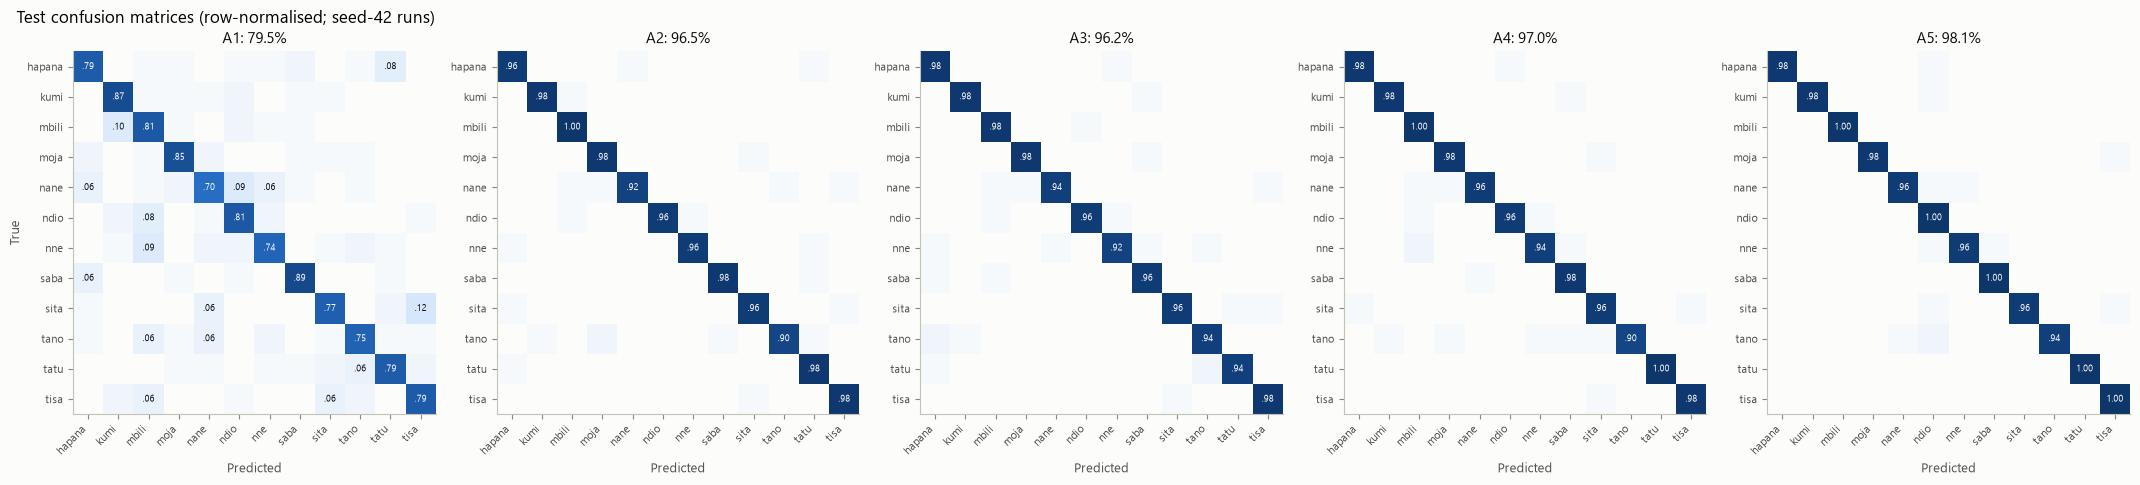

,tisa/sita,nne/nane,tatu/tano,saba/sita
A1,8.6%,4.7%,3.8%,0.0%
A2,1.9%,0.0%,1.0%,0.0%
A3,1.9%,0.9%,1.9%,0.0%
A4,1.9%,0.0%,0.0%,0.0%
A5,1.0%,0.9%,0.0%,0.0%


In [8]:
shown = [a for a in APPROACHES if 42 in P.get(a, {})]
fig, axes = plt.subplots(1, len(shown), figsize=(4.3 * len(shown), 4.6))
for ax, a in zip(np.atleast_1d(axes), shown):
    plot_confusion_matrix(y_test, P[a][42].argmax(1), NAMES, ax=ax, colorbar=False,
                          title=f"{a}: {M[a][42]['accuracy']:.1%}")
    if a != shown[0]:
        ax.set_ylabel("")
fig.suptitle("Test confusion matrices (row-normalised; seed-42 runs)", x=0.01, ha="left", fontsize=12)
fig.tight_layout()
save_figure(fig, "test_confusion_grid")
plt.show()

pair_table = pd.DataFrame({a: {f"{x}/{y}": pair_confusion(y_test, P[a][42].argmax(1), NAMES, x, y) for x, y in KEY_PAIRS}
                           for a in shown}).T
display(pair_table.style.format("{:.1%}").set_caption("Sound-alike pairs: share of the pair's clips heard as the other word"))

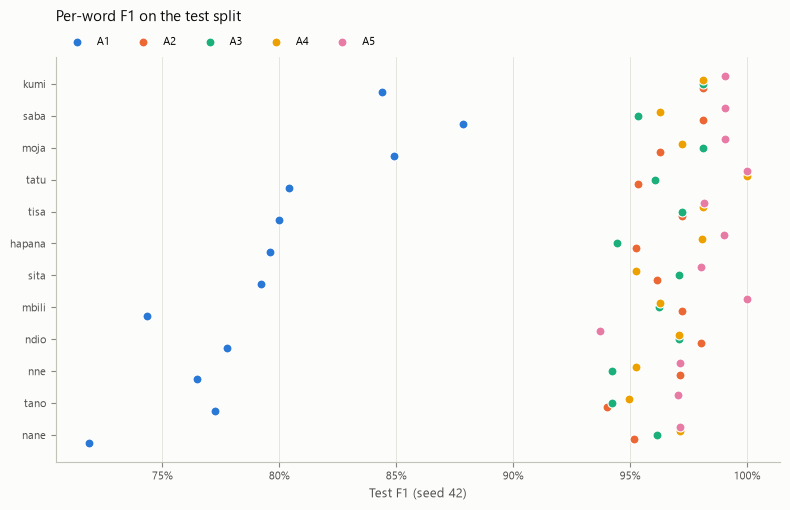

In [9]:
f1 = pd.DataFrame({a: {w: M[a][42]["per_class"][w]["f1"] for w in NAMES} for a in shown})
order = f1.mean(axis=1).sort_values().index           # hardest words at the bottom
fig, ax = plt.subplots(figsize=(8, 5.2))
for i, a in enumerate(shown):
    ax.scatter(f1.loc[order, a], np.arange(len(order)) + (i - (len(shown) - 1) / 2) * 0.13, s=42,
               color=MODEL_COLORS[a], label=a, zorder=3, edgecolor="white", linewidth=0.8)
ax.set_yticks(np.arange(len(order)), order)
ax.set_xlabel("Test F1 (seed 42)")
ax.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.grid(axis="y", visible=False)
ax.legend(loc="lower left", ncol=len(shown), frameon=False, bbox_to_anchor=(0, 1.0))
ax.set_title("Per-word F1 on the test split", loc="left", pad=26)
fig.tight_layout()
save_figure(fig, "test_per_word_f1")
plt.show()

### Calibration: reliability before and after temperature scaling (test, seed 42)
Each run's temperature was fitted on validation and applied unchanged to the test split. A1 is omitted: logistic regression was already calibrated (its fitted temperature was 0.99), so it is used without scaling.

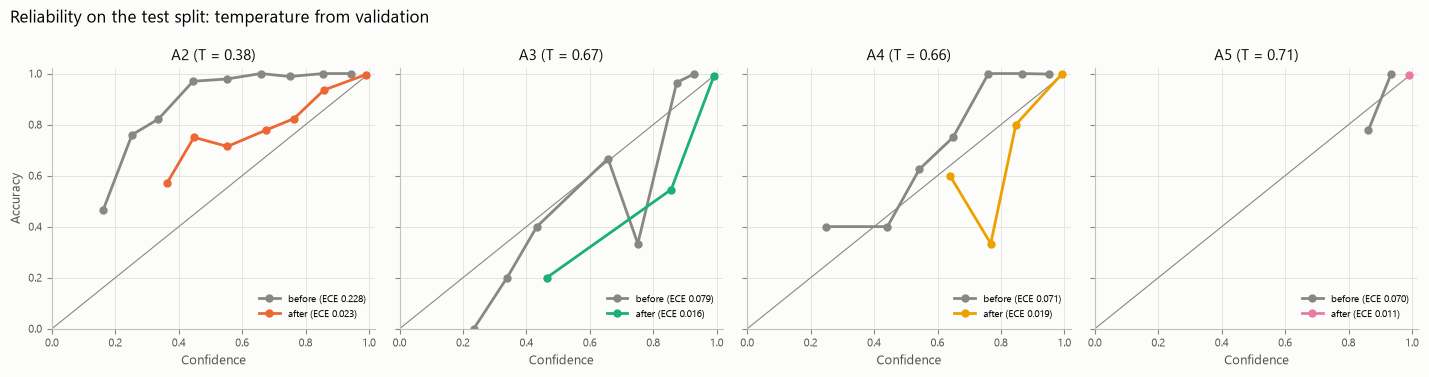

In [10]:
calibrated = [a for a in shown if a != "A1"]
fig, axes = plt.subplots(1, len(calibrated), figsize=(3.6 * len(calibrated), 3.8), sharey=True)
for ax, a in zip(np.atleast_1d(axes), calibrated):
    before = test_probs(FINAL[a][0], 42, "test-uncalibrated")
    ece0, ece1 = compute_metrics(y_test, before)["ece"], M[a][42]["ece"]
    ax.plot([0, 1], [0, 1], color=INK_MUTED, lw=0.8)
    for probs, label, color in ((before, f"before (ECE {ece0:.3f})", INK_MUTED), (P[a][42], f"after (ECE {ece1:.3f})", MODEL_COLORS[a])):
        c = reliability_curve(y_test, probs, n_bins=10)
        c = c[c["count"] >= 5]                       # bins with at least 5 clips
        ax.plot(c["confidence"], c["accuracy"], marker="o", ms=5, lw=2, color=color, label=label)
    T = logged(FINAL[a][0], 42)["extra"]["temperature"]
    ax.set(title=f"{a} (T = {T:.2f})", xlabel="Confidence", xlim=(0, 1.02), ylim=(0, 1.02))
    ax.legend(loc="lower right", fontsize=7.5, frameon=False)
np.atleast_1d(axes)[0].set_ylabel("Accuracy")
fig.suptitle("Reliability on the test split: temperature from validation", x=0.01, ha="left", fontsize=12)
fig.tight_layout()
save_figure(fig, "test_reliability")
plt.show()

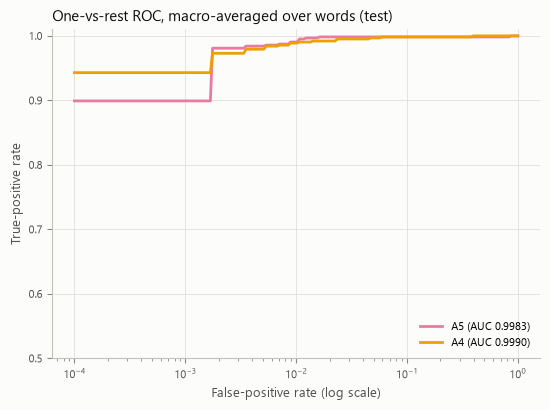

In [11]:
# One-vs-rest ROC, macro-averaged over the 12 words, for the two best models on validation (A5 and A4).
top2 = [a for a in ("A5", "A4") if 42 in P.get(a, {})]
grid = np.logspace(-4, 0, 200)
fig, ax = plt.subplots(figsize=(5.6, 4.2))
for a in top2:
    tprs = []
    for k in range(len(NAMES)):
        fpr, tpr, _ = roc_curve(y_test == k, P[a][42][:, k])
        tprs.append(np.interp(grid, fpr, tpr))
    ax.plot(grid, np.mean(tprs, axis=0), lw=2, color=MODEL_COLORS[a], label=f"{a} (AUC {M[a][42]['roc_auc_ovr']:.4f})")
ax.set_xscale("log")
ax.set(xlabel="False-positive rate (log scale)", ylabel="True-positive rate", ylim=(0.5, 1.01))
ax.legend(loc="lower right", frameon=False)
ax.set_title("One-vs-rest ROC, macro-averaged over words (test)", loc="left")
fig.tight_layout()
save_figure(fig, "test_roc_top2")
plt.show()

**Observations (where the errors are)**
- **The sound-alike pairs stay solved for the order-aware models.** On test, A2–A5 confuse *tisa/sita* in 1.0–1.9% of the pair's clips, against 8.6% for A1. *nne/nane* and *tatu/tano* are at 0–1.9%, and *saba/sita* is at 0% for every model.
- **The errors are shared, as on validation.**
  - All 12 of A5's test errors are also A4 errors, and 10 of them defeat A2, A3, A4 and A5 alike.
  - One test clip labelled *sita* is heard as *tisa* by all four models with 99–100% confidence: another label-noise candidate for Phase 8.
- **A5's fallback word is *ndio*.** When unsure, A5 tends to answer *ndio* (yes): 6 of its 12 errors, four of them with low confidence (26–47%). So *ndio* has A5's lowest F1 (93.7%). The other models spread their uncertain errors over many words.
- **Calibration:** before scaling, every model is *under*-confident. Label smoothing teaches them to hold back, and the HMM's raw scores are especially flat (A2: ECE 0.228). The temperatures fitted on validation (0.38–0.71, all sharpening) bring the test ECE down to 0.011–0.023.
- **ROC:** both models are close to perfect at ranking (AUC 0.998–0.999). A4's AUC is slightly higher than A5's, because A5's few high-confidence errors cost it at the very lowest false-positive rates.

### How much labelled speech is needed? (R4, test split)

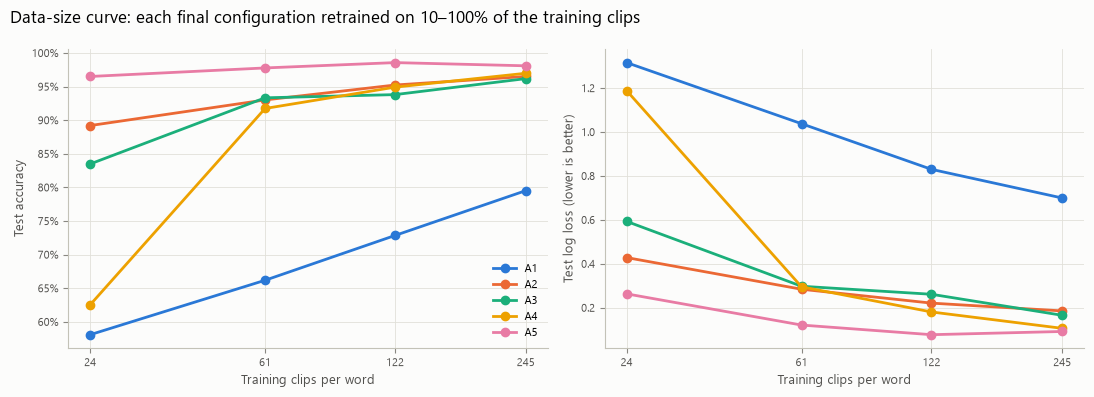

fraction,0.100000,0.250000,0.500000,1.000000
approach,,,,
A1,58.1%,66.2%,72.9%,79.5%
A2,89.2%,93.0%,95.2%,96.5%
A3,83.5%,93.3%,93.8%,96.2%
A4,62.5%,91.7%,94.9%,97.0%
A5,96.5%,97.8%,98.6%,98.1%


In [12]:
curve = pd.DataFrame(r4_rows)
full = pd.DataFrame([{"approach": a, "fraction": 1.0, "clips per word": len(train) / len(NAMES),
                      "test log loss": M[a][42]["log_loss"], "test accuracy": M[a][42]["accuracy"]} for a in shown])
curve = pd.concat([curve, full], ignore_index=True).sort_values(["approach", "fraction"])
curve.to_csv(results_dir() / "metrics" / "data_size_curve.csv", index=False)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for a, g in curve.groupby("approach"):
    for ax, col in zip(axes, ("test accuracy", "test log loss")):
        ax.plot(g["clips per word"], g[col], marker="o", ms=6, lw=2, color=MODEL_COLORS[a], label=a)
for ax, col in zip(axes, ("Test accuracy", "Test log loss (lower is better)")):
    ax.set_xscale("log")
    ticks = sorted(curve["clips per word"].round().unique())
    ax.set_xticks(ticks, [f"{t:.0f}" for t in ticks])
    ax.minorticks_off()
    ax.set(xlabel="Training clips per word", ylabel=col)
axes[0].yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
axes[0].legend(loc="lower right", frameon=False)
fig.suptitle("Data-size curve: each final configuration retrained on 10–100% of the training clips", x=0.01, ha="left",
             fontsize=12)
fig.tight_layout()
save_figure(fig, "data_size_curve")
plt.show()
display(curve.pivot(index="approach", columns="fraction", values="test accuracy").style.format("{:.1%}")
        .set_caption("Test accuracy by share of the training clips"))

**Observations (data-size curve)**
- **Pretraining pays off most when data is scarce.** With only 24 clips per word (10%), A5 reaches 96.5% test accuracy. That is more than A2, A3 or A4 reach with all 245 clips per word. At 61 clips per word it reaches 97.8%.
- **Without pretraining, the HMM is the most data-efficient model.** At 24 clips per word, A2 reaches 89.2%, against 83.5% (A3), 62.5% (A4) and 58.1% (A1). From 61 clips per word on, the neural models catch up on accuracy (91.7–93.3%). On log loss, A4 overtakes the HMM from 122 clips per word, but A3 only with the full split.
- **A4 is the most data-hungry, partly because of the fixed recipe.**
  - At 10%, A3 and A4 were still improving at their last epoch (40 of 40), and so was A5 (10 of 10). The unchanged recipe gives a tenth of the data a tenth of the optimisation steps.
  - So the 10% points understate what longer training could reach, A4's most of all. Comparing equal numbers of steps would separate data from compute.
- **A5 has saturated by about 120 clips per word.** Its 50% point (98.6%, log loss 0.077) is even slightly better than its 100% point (98.1%, 0.092). With one seed and intervals of about ±0.05, that is noise, not a real gain.
- **A1 improves steadily (58% → 80%) but stays far below.** More data cannot make up for features that discard the order of the sounds.
- **One seed per point:** each point is a single training run, so small differences between neighbouring points are not meaningful.

### Efficiency
Parameters, model size (32-bit weights), training time of the final run, and CPU latency per clip. Latency is measured from the audio file to probabilities (loading, cropping, features and model), on **one CPU thread**, as a phone or an interactive voice-response server might run it. It is the median over test clips, measured once and cached.

In [13]:
EFF = find("metrics", "efficiency.csv")


def a2_param_count(hmm):
    return int(sum(np.size(getattr(m, att)) for m in hmm.models_
                   for att in ("startprob_", "transmat_", "weights_", "means_", "covars_")))


def measure_latency(n_clips):
    '''Median single-thread ms per clip, audio file -> probabilities, for each final seed-42 model.'''
    torch.set_num_threads(1)
    clips = test.path.iloc[:n_clips].tolist()
    out = {}
    for a in APPROACHES:
        exp_id = FINAL[a][0]
        rec = logged(exp_id, 42)
        cfg = rec["params"]
        if a == "A1":
            X = cached_features(train, **cfg["features"])
            model = make_a1(cfg["kind"]).set_params(clf__C=rec["extra"]["best_params"]["C"]).fit(X, y_tr)
            run = lambda p: model.predict_proba(extract(p, **cfg["features"])[None])
            size = sum(np.size(x) for x in (model[-1].coef_, model[-1].intercept_, model[0].mean_, model[0].scale_))
        elif a == "A2":
            hmm = pickle.loads(checkpoint_file(f"{exp_id}_seed42_hmm.pkl").read_bytes())
            _, scaler = a2_sequences(cfg, train)
            run = lambda p: hmm.scores(scaler.transform(utterance_cmvn([extract(p, **cfg["features"])])))
            size = a2_param_count(hmm)
        else:
            path = checkpoint_file(f"{exp_id}_seed42.pt")
            if not path.exists():
                continue
            model_cfg = {k: cfg[k] for k in ("features", "model", "train", "augment")}
            n_feat = extract(test.path.iloc[0], **cfg["features"]).shape[-1]
            model, scaler, _ = load_checkpoint(path, lambda: network(a, model_cfg, n_feat, pretrained=False))
            def run(p, model=model, scaler=scaler, feat=cfg["features"]):
                with torch.no_grad():
                    return model(torch.from_numpy(scaler.transform(extract(p, **feat)[None])))
            size = count_all_parameters(model)[0]
        run(clips[0])                                         # warm-up
        times = []
        for p in clips[: (10 if a == "A5" else n_clips)]:
            start = time.perf_counter()
            run(p)
            times.append((time.perf_counter() - start) * 1000)
        out[a] = {"parameters": int(size), "latency ms/clip": float(np.median(times))}
    torch.set_num_threads(os.cpu_count() or 4)
    return out


if EFF.exists() and not SMOKE:
    eff = pd.read_csv(EFF, index_col=0)
else:
    lat = measure_latency(n_clips=4 if SMOKE else 50)
    eff = pd.DataFrame(lat).T
    eff.index.name = "approach"
    eff["size MB (32-bit)"] = eff["parameters"] * 4 / 1e6
    eff["train minutes (final run)"] = [float(json.loads(find("runs", f"{FINAL[a][0]}_seed42.json").read_text())["train_time_min"])
                                        for a in eff.index]
    eff["train device"] = [json.loads(find("runs", f"{FINAL[a][0]}_seed42.json").read_text())["gpu"] for a in eff.index]
    eff["latency measured on"] = f"{platform.processor() or platform.machine()} ({platform.system()}), 1 thread"
    eff.to_csv(results_dir() / "metrics" / "efficiency.csv")
display(eff.style.format({"parameters": "{:,.0f}", "latency ms/clip": "{:.1f}", "size MB (32-bit)": "{:.2f}",
                          "train minutes (final run)": "{:.1f}"}))

,parameters,latency ms/clip,size MB (32-bit),train minutes (final run),train device,latency measured on
approach,,,,,,
A1,"2,196",7.2,0.01,0.1,cpu,"x86_64 (Linux), 1 thread"
A2,"92,880",112.9,0.37,11.0,cpu,"x86_64 (Linux), 1 thread"
A3,"855,052",13.8,3.42,1.2,Tesla T4,"x86_64 (Linux), 1 thread"
A4,"149,988",9.1,0.60,1.0,Tesla T4,"x86_64 (Linux), 1 thread"
A5,"315,704,204",870.8,1262.82,13.0,Tesla T4,"x86_64 (Linux), 1 thread"


**Observations (efficiency)**
- **Latency, one CPU thread, from audio file to probabilities:** A1 7 ms, A4 9 ms, A3 14 ms, A2 113 ms, A5 871 ms per clip.
  - The HMM is slow because it scores the clip under 12 word models with the forward algorithm.
- **Model size (32-bit weights):** A1 9 KB, A2 0.37 MB, A4 0.60 MB, A3 3.4 MB, A5 1.26 GB.
- **The trade-off is stark.** A5 is about 96× slower than A4 and about 2,100× larger. In return it has 0.032 lower test log loss (0.093 vs 0.125, seed means) and 1.8 more points of accuracy.
  - For a phone or a cheap voice-response server, A4 is the natural choice: 9 ms and 0.6 MB, at 96–97% accuracy.
  - Where every error costs (for example confirming a mobile-money amount), A5 is worth its cost.
- **Training cost of the final run:** about 13 min for A5 and about 1 min for A3 and A4 on the T4, 11 min for A2 on CPU, and seconds for A1. The whole study used a few GPU hours (see the limitations section).
- Latency was measured once on the Kaggle machine's CPU (x86-64 Linux), so the absolute values depend on that machine. The ratios between models are what transfer.

### Tables for the report

In [14]:
def latex_table(results, eff):
    lines = [r"\begin{tabular}{@{}lrrrcccc@{}}", r"\toprule",
             r"Approach & Params & Train (min) & CPU ms/clip & Log loss & Accuracy (\%) & Macro-F1 & ECE \\", r"\midrule"]
    names = {"A1": "A1 MFCC stats + LR", "A2": "A2 GMM-HMM", "A3": "A3 BiLSTM + attention", "A4": "A4 TC-ResNet",
             "A5": "A5 XLS-R (fine-tuned)"}
    for a, r in results.iterrows():
        e = eff.loc[a] if a in eff.index else None
        params = "" if e is None else (f"{e['parameters'] / 1e6:.0f}M" if e["parameters"] >= 1e6 else f"{e['parameters'] / 1e3:.0f}K")
        train_min = "" if e is None else f"{e['train minutes (final run)']:.1f}"
        latency = "" if e is None else f"{e['latency ms/clip']:.0f}"
        pm = lambda s: s.replace(" ± ", r" $\pm$ ")
        lines.append(f"{names[a]} & {params} & {train_min} & {latency} & {pm(r['test log loss'])} & "
                     f"{pm(r['test accuracy %'])} & {pm(r['test macro-F1'])} & {pm(r['ECE'])} \\\\")
    lines += [r"\bottomrule", r"\end{tabular}"]
    return "\n".join(lines) + "\n"


tables = results_dir() / "tables"
tables.mkdir(parents=True, exist_ok=True)
(tables / "test_results.tex").write_text(latex_table(results, eff), encoding="utf-8")
print((tables / "test_results.tex").read_text(encoding="utf-8"))
table = build_experiment_table()
display(table[table.test_logloss.astype(str).str.len() > 0][["exp_id", "seed", "val_logloss", "test_logloss", "val_acc",
                                                             "test_acc"]].reset_index(drop=True))

\begin{tabular}{@{}lrrrcccc@{}}
\toprule
Approach & Params & Train (min) & CPU ms/clip & Log loss & Accuracy (\%) & Macro-F1 & ECE \\
\midrule
A1 MFCC stats + LR & 2K & 0.1 & 7 & 0.700 & 79.5 & 0.795 & 0.047 \\
A2 GMM-HMM & 93K & 11.0 & 113 & 0.186 & 96.5 & 0.965 & 0.023 \\
A3 BiLSTM + attention & 855K & 1.2 & 14 & 0.170 $\pm$ 0.009 & 96.0 $\pm$ 0.3 & 0.960 $\pm$ 0.003 & 0.017 $\pm$ 0.001 \\
A4 TC-ResNet & 150K & 1.0 & 9 & 0.125 $\pm$ 0.026 & 96.3 $\pm$ 1.2 & 0.963 $\pm$ 0.012 & 0.019 $\pm$ 0.003 \\
A5 XLS-R (fine-tuned) & 316M & 13.0 & 871 & 0.093 $\pm$ 0.001 & 98.1 $\pm$ 0.1 & 0.982 $\pm$ 0.001 & 0.014 $\pm$ 0.003 \\
\bottomrule
\end{tabular}



,exp_id,seed,val_logloss,test_logloss,val_acc,test_acc
0,A1-R0-03,42,0.7250,0.6997,0.7794,0.7952
1,A1-R4-01,42,1.3216,1.3161,0.5810,0.581
2,A1-R4-02,42,1.0569,1.038,0.6905,0.6619
3,A1-R4-03,42,0.8741,0.8302,0.7302,0.7286
4,A2-R2-03,42,0.1799,0.1857,0.9524,0.9651
5,A2-R4-01,42,0.4324,0.4286,0.8968,0.8921
6,A2-R4-02,42,0.2917,0.2844,0.9238,0.9302
7,A2-R4-03,42,0.2127,0.2212,0.9429,0.9524
8,A3-R3-01,7,0.1413,0.164,0.9698,0.9619
9,A3-R3-01,13,0.1352,0.1812,0.9667,0.9571
